Get background and background noise

In [91]:
from photutils.background import Background2D,MedianBackground
from astropy.stats import SigmaClip
import numpy as np
import scipy
import matplotlib.pyplot as plt
from astropy.io import fits
import os
from astropy.stats import sigma_clipped_stats,gaussian_sigma_to_fwhm
from astropy.table import QTable
from photutils.background import LocalBackground, MMMBackground
from photutils.detection import DAOStarFinder
from photutils.psf import IterativePSFPhotometry, IntegratedGaussianPRF

Red Filter

In [92]:
sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()

dir_red = "m57_red_resize/"
fits_file = sorted([f for f in os.listdir(dir_red) if f.endswith(".fits")])[0]
stack_median_red = fits.getdata(os.path.join(dir_red, fits_file))


bkg = Background2D(stack_median_red,(50,50),filter_size=(7,7),sigma_clip=sigma_clip,bkg_estimator=bkg_estimator)
print("      Median background found: %f, median bkg noise: %f"
      %(bkg.background_median,bkg.background_rms_median))


# subtração do background 2D
image_sub = stack_median_red - bkg.background
fits.writeto("m57_red_bkg/m57_red_bkg.fits", image_sub, overwrite=True)

# exemplo de região do background (ajusta coordenadas)
y1, y2, x1, x2 = 0, 100, 300, 400
mean_bkg_region = np.mean(image_sub[y1:y2, x1:x2])

print("Média da região de background (pós-subtração):", mean_bkg_region)

      Median background found: 230.714508, median bkg noise: 4.138648
Média da região de background (pós-subtração): -0.5535962


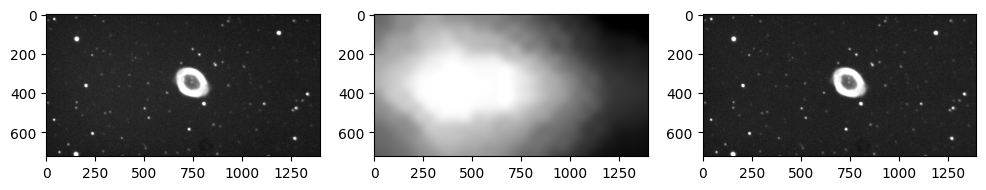

In [93]:
fig,ax = plt.subplots(1,3,figsize=(12,6))
lo,up = np.percentile(stack_median_red,1),np.percentile(stack_median_red,99)
ax[0].imshow(stack_median_red,cmap='gray',clim=(lo,up))
lo,up = np.percentile(bkg.background,1),np.percentile(bkg.background,95)
ax[1].imshow(bkg.background,cmap='gray',clim=(lo,up))
lo,up = np.percentile(stack_median_red - bkg.background,1),np.percentile(stack_median_red-bkg.background,99)
ax[2].imshow(image_sub,cmap='gray',clim=(lo,up))


Just DAOStarFinder

     Found 71 stars in image 


Text(0, 0.5, 'y (pix)')

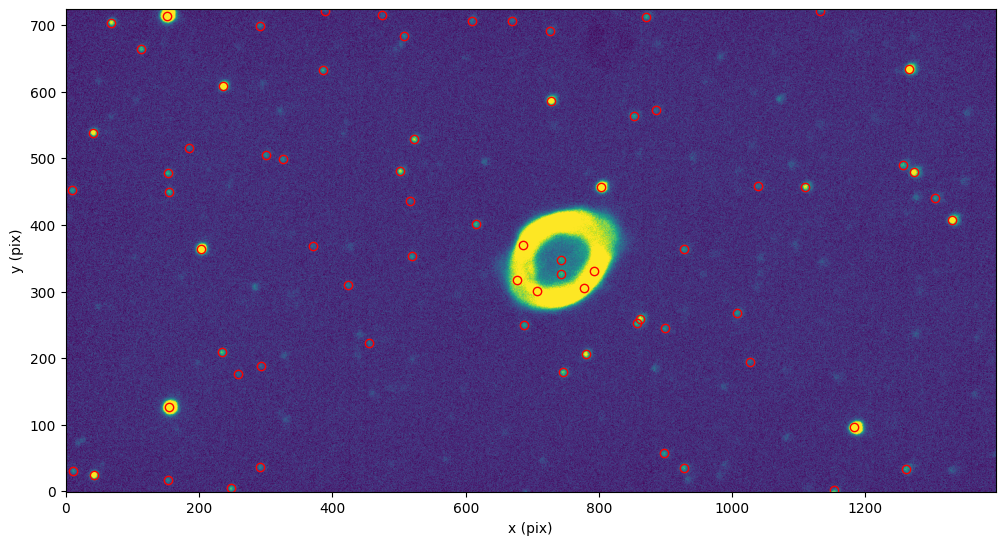

In [94]:
## Get background
mean, median, std = sigma_clipped_stats(image_sub, sigma=3.0, maxiters=20)

## Find stars
daofind = DAOStarFinder(fwhm=10.0, threshold=7*std)  ##peakmax pode ser usado para excluir saturadas
sources = daofind(image_sub - median) #table with inf. of stars

print("     Found %i stars in image " % len(sources))

fig = plt.figure(figsize=(12,7))
l1 = np.percentile(image_sub[np.isfinite(image_sub)].flatten(), 1)
l2 = np.percentile(image_sub[np.isfinite(image_sub)].flatten(), 99)
plt.imshow(image_sub,clim=(l1,l2),origin='lower')
plt.plot(sources["xcentroid"],sources["ycentroid"],'or',mfc='none')
plt.xlabel("x (pix)")
plt.ylabel("y (pix)")

Background médio: -0.10744537


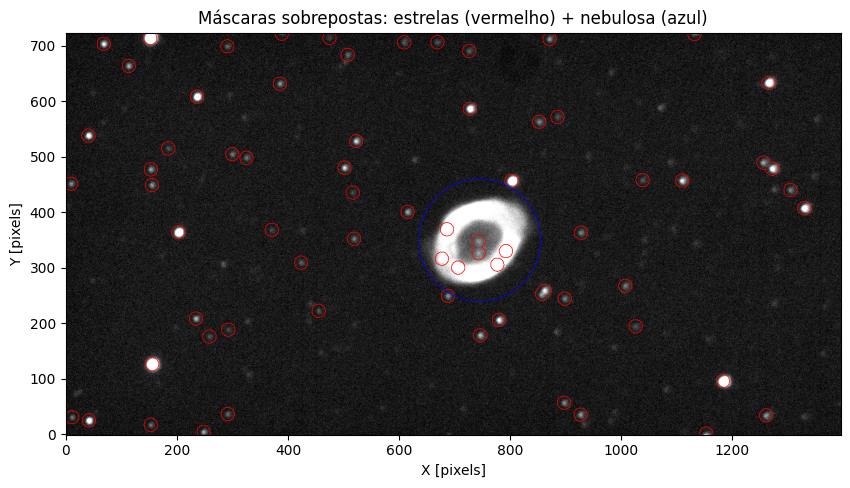

In [95]:
mask_stars = np.zeros(image_sub.shape, dtype=bool)

for star in sources:
    x = star['xcentroid']
    y = star['ycentroid']
    r = 12  # raio em pixels (ajuste conforme necessário)

    Y, X = np.ogrid[:image_sub.shape[0], :image_sub.shape[1]]
    dist = np.sqrt((X - x)**2 + (Y - y)**2)
    mask_stars[dist <= r] = True



mask_nebula = np.zeros(image_sub.shape, dtype=bool)

yc, xc = 350,745   # centro da nebulosa
r_neb = 110         # raio em pixels

Y, X = np.ogrid[:image_sub.shape[0], :image_sub.shape[1]]
dist = np.sqrt((X - xc)**2 + (Y - yc)**2)
mask_nebula[dist <= r_neb] = True


mask_total = mask_stars | mask_nebula

background_values = image_sub[~mask_total]
mean_background = np.mean(background_values)
print("Background médio:", mean_background)


# --- Plot da imagem ---
plt.figure(figsize=(10,10))
plt.imshow(image_sub, origin='lower', cmap='gray', vmin=np.percentile(image_sub, 5), vmax=np.percentile(image_sub, 99))

# --- Máscara das estrelas em vermelho ---
plt.contour(mask_stars, colors='red', linewidths=0.5)

# --- Máscara da nebulosa em azul ---
plt.contour(mask_nebula, colors='blue', linewidths=0.5)

plt.title("Máscaras sobrepostas: estrelas (vermelho) + nebulosa (azul)")
plt.xlabel("X [pixels]")
plt.ylabel("Y [pixels]")
plt.show()

Blue Filter

In [96]:
sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()

dir_blue = "m57_blue_resize/"
fits_file = sorted([f for f in os.listdir(dir_blue) if f.endswith(".fits")])[0]
stack_median_blue = fits.getdata(os.path.join(dir_blue, fits_file))


bkg = Background2D(stack_median_blue,(50,50),filter_size=(7,7),sigma_clip=sigma_clip,bkg_estimator=bkg_estimator)
print("      Median background found: %f, median bkg noise: %f"
      %(bkg.background_median,bkg.background_rms_median))

# subtração do background 2D
image_sub_blue = stack_median_blue - bkg.background
fits.writeto("m57_blue_bkg/m57_blue_bkg.fits", image_sub_blue, overwrite=True)

# exemplo de região do background (ajusta coordenadas)
y1, y2, x1, x2 = 0, 100, 300, 400
mean_bkg_region = np.mean(image_sub_blue[y1:y2, x1:x2])

print("Média da região de background (pós-subtração):", mean_bkg_region)

      Median background found: 44.929451, median bkg noise: 2.116906
Média da região de background (pós-subtração): 0.030841587


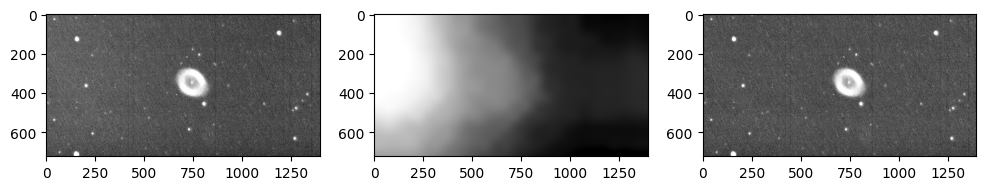

In [97]:
fig,ax = plt.subplots(1,3,figsize=(12,6))
lo,up = np.percentile(stack_median_blue,1),np.percentile(stack_median_blue,99)
ax[0].imshow(stack_median_blue,cmap='gray',clim=(lo,up))
lo,up = np.percentile(bkg.background,1),np.percentile(bkg.background,95)
ax[1].imshow(bkg.background,cmap='gray',clim=(lo,up))
lo,up = np.percentile(stack_median_blue-bkg.background,1),np.percentile(stack_median_blue-bkg.background,99)
ax[2].imshow(image_sub_blue,cmap='gray',clim=(lo,up))

     Found 46 stars in image 


Text(0, 0.5, 'y (pix)')

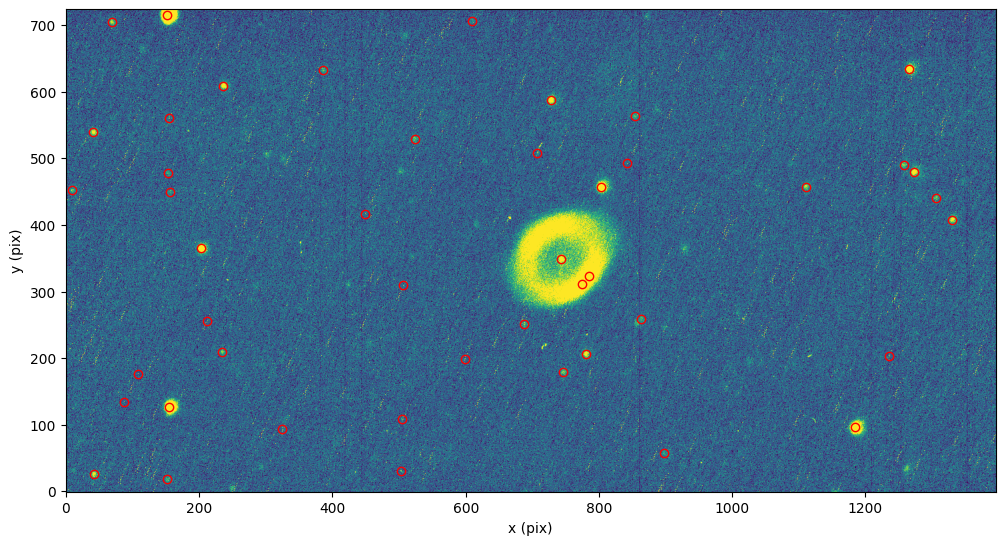

In [98]:
## Get background
mean, median, std = sigma_clipped_stats(image_sub_blue, sigma=2.0, maxiters=20)

## Find stars
daofind = DAOStarFinder(fwhm=10.0, threshold=7*std)  ##peakmax pode ser usado para excluir saturadas
sources = daofind(image_sub_blue - median) #table with inf. of stars

print("     Found %i stars in image " % len(sources))

fig = plt.figure(figsize=(12,7))
l1 = np.percentile(image_sub_blue[np.isfinite(image_sub_blue)].flatten(), 1)
l2 = np.percentile(image_sub_blue[np.isfinite(image_sub_blue)].flatten(), 99)
plt.imshow(image_sub_blue,clim=(l1,l2),origin='lower')
plt.plot(sources["xcentroid"],sources["ycentroid"],'or',mfc='none')
plt.xlabel("x (pix)")
plt.ylabel("y (pix)")

Background médio: 0.057477765


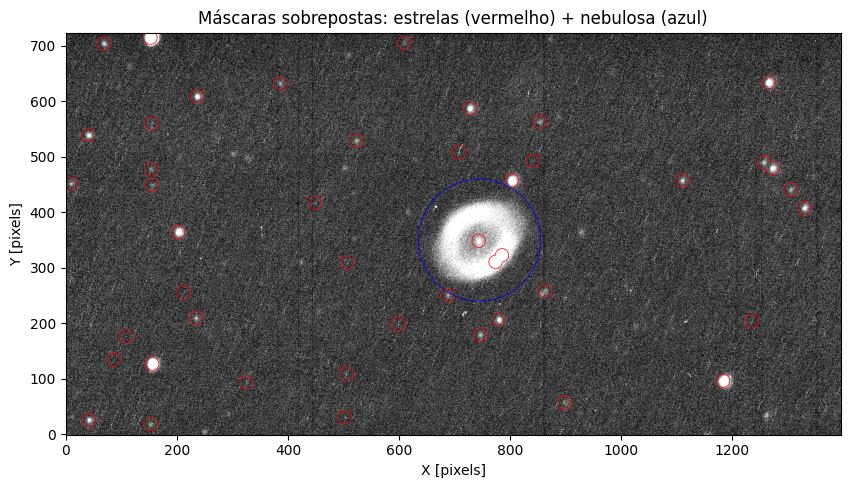

In [99]:
mask_stars = np.zeros(image_sub_blue.shape, dtype=bool)

for star in sources:
    x = star['xcentroid']
    y = star['ycentroid']
    r = 12  # raio em pixels (ajuste conforme necessário)

    Y, X = np.ogrid[:image_sub_blue.shape[0], :image_sub_blue.shape[1]]
    dist = np.sqrt((X - x)**2 + (Y - y)**2)
    mask_stars[dist <= r] = True

mask_nebula = np.zeros(image_sub_blue.shape, dtype=bool)

yc, xc = 350, 745   # centro da nebulosa
r_neb = 110         # raio em pixels

Y, X = np.ogrid[:image_sub_blue.shape[0], :image_sub_blue.shape[1]]
dist = np.sqrt((X - xc)**2 + (Y - yc)**2)
mask_nebula[dist <= r_neb] = True

mask_total = mask_stars | mask_nebula

background_values = image_sub_blue[~mask_total]
mean_background = np.mean(background_values)
print("Background médio:", mean_background)

# --- Plot da imagem ---
plt.figure(figsize=(10,10))
plt.imshow(image_sub_blue, origin='lower', cmap='gray',
           vmin=np.percentile(image_sub_blue, 5),
           vmax=np.percentile(image_sub_blue, 99))

# --- Máscara das estrelas em vermelho ---
plt.contour(mask_stars, colors='red', linewidths=0.5)

# --- Máscara da nebulosa em azul ---
plt.contour(mask_nebula, colors='blue', linewidths=0.5)

plt.title("Máscaras sobrepostas: estrelas (vermelho) + nebulosa (azul)")
plt.xlabel("X [pixels]")
plt.ylabel("Y [pixels]")
plt.show()


Green Filter

In [100]:
sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()

dir_green = "m57_green_resize/"
fits_file = sorted([f for f in os.listdir(dir_green) if f.endswith(".fits")])[0]
stack_median_green = fits.getdata(os.path.join(dir_green, fits_file))


bkg = Background2D(stack_median_green,(50,50),filter_size=(7,7),sigma_clip=sigma_clip,bkg_estimator=bkg_estimator)
print("      Median background found: %f, median bkg noise: %f"
      %(bkg.background_median,bkg.background_rms_median))

# subtração do background 2D
image_sub_green = stack_median_green - bkg.background
fits.writeto("m57_green_bkg/m57_green_bkg.fits", image_sub_green, overwrite=True)

# exemplo de região do background (ajusta coordenadas)
y1, y2, x1, x2 = 0, 100, 300, 400
mean_bkg_region = np.mean(image_sub_green[y1:y2, x1:x2])

print("Média da região de background (pós-subtração):", mean_bkg_region)

      Median background found: 167.078125, median bkg noise: 2.936447
Média da região de background (pós-subtração): -0.03733664


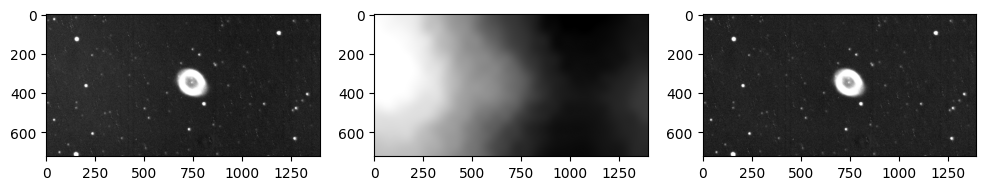

In [101]:
fig,ax = plt.subplots(1,3,figsize=(12,6))
lo,up = np.percentile(stack_median_green,1),np.percentile(stack_median_green,99)
ax[0].imshow(stack_median_green,cmap='gray',clim=(lo,up))
lo,up = np.percentile(bkg.background,1),np.percentile(bkg.background,95)
ax[1].imshow(bkg.background,cmap='gray',clim=(lo,up))
lo,up = np.percentile(stack_median_green-bkg.background,1),np.percentile(stack_median_green-bkg.background,99)
ax[2].imshow(image_sub_green,cmap='gray',clim=(lo,up))

Found 78 stars in image


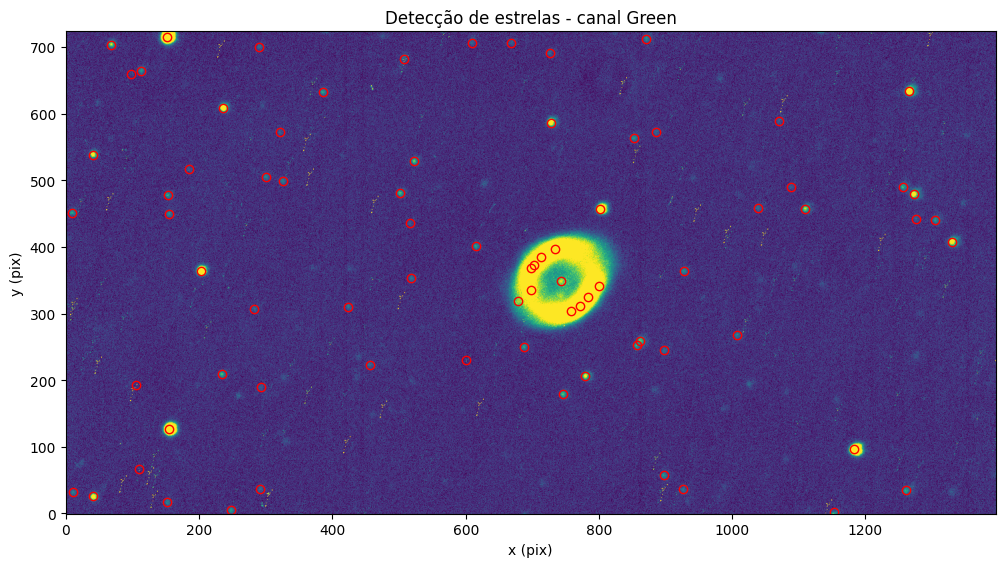

In [102]:
## Get background
mean, median, std = sigma_clipped_stats(image_sub_green, sigma=3.0, maxiters=20)

## Find stars
daofind = DAOStarFinder(fwhm=10.0, threshold=7*std)  ##peakmax pode ser usado para excluir saturadas
sources = daofind(image_sub_green - median)  # table with info of stars

print("Found %i stars in image" % len(sources))

# --- Plot da imagem ---
fig = plt.figure(figsize=(12,7))
l1 = np.percentile(image_sub_green[np.isfinite(image_sub_green)].flatten(), 1)
l2 = np.percentile(image_sub_green[np.isfinite(image_sub_green)].flatten(), 99)
plt.imshow(image_sub_green, clim=(l1, l2), origin='lower')
plt.plot(sources["xcentroid"], sources["ycentroid"], 'or', mfc='none')
plt.xlabel("x (pix)")
plt.ylabel("y (pix)")
plt.title("Detecção de estrelas - canal Green")
plt.show()


Background médio: 0.07312096


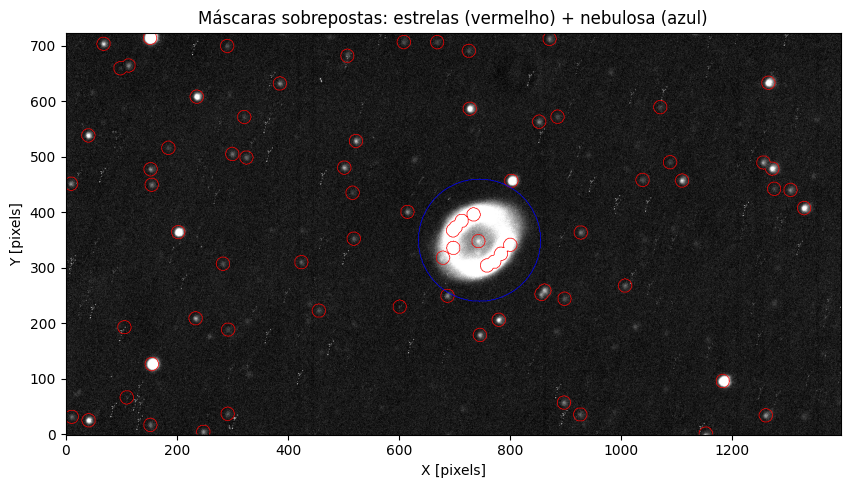

In [103]:
mask_stars = np.zeros(image_sub_green.shape, dtype=bool)

for star in sources:
    x = star['xcentroid']
    y = star['ycentroid']
    r = 12  # raio em pixels (ajuste conforme necessário)

    Y, X = np.ogrid[:image_sub_green.shape[0], :image_sub_green.shape[1]]
    dist = np.sqrt((X - x)**2 + (Y - y)**2)
    mask_stars[dist <= r] = True

mask_nebula = np.zeros(image_sub_green.shape, dtype=bool)

yc, xc = 350, 745   # centro da nebulosa
r_neb = 110         # raio em pixels

Y, X = np.ogrid[:image_sub_green.shape[0], :image_sub_green.shape[1]]
dist = np.sqrt((X - xc)**2 + (Y - yc)**2)
mask_nebula[dist <= r_neb] = True

mask_total = mask_stars | mask_nebula

background_values = image_sub_green[~mask_total]
mean_background = np.mean(background_values)
print("Background médio:", mean_background)

# --- Plot da imagem ---
plt.figure(figsize=(10,10))
plt.imshow(image_sub_green, origin='lower', cmap='gray',
           vmin=np.percentile(image_sub_green, 5),
           vmax=np.percentile(image_sub_green, 99))

# --- Máscara das estrelas em vermelho ---
plt.contour(mask_stars, colors='red', linewidths=0.5)

# --- Máscara da nebulosa em azul ---
plt.contour(mask_nebula, colors='blue', linewidths=0.5)

plt.title("Máscaras sobrepostas: estrelas (vermelho) + nebulosa (azul)")
plt.xlabel("X [pixels]")
plt.ylabel("Y [pixels]")
plt.show()


Black Filter

In [104]:
sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()

dir_black = "m57_black_resize/"
fits_file = sorted([f for f in os.listdir(dir_black) if f.endswith(".fits")])[0]
stack_median_black = fits.getdata(os.path.join(dir_black, fits_file))


bkg = Background2D(stack_median_black,(70,70),filter_size=(7,7),sigma_clip=sigma_clip,bkg_estimator=bkg_estimator)
print("      Median background found: %f, median bkg noise: %f"
      %(bkg.background_median,bkg.background_rms_median))


# subtração do background 2D
image_sub_black = stack_median_black - bkg.background
fits.writeto("m57_black_bkg/m57_black_bkg.fits", image_sub_black, overwrite=True)

# exemplo de região do background (ajusta coordenadas)
y1, y2, x1, x2 = 0, 100, 300, 400
mean_bkg_region = np.mean(image_sub_black[y1:y2, x1:x2])

print("Média da região de background (pós-subtração):", mean_bkg_region)

      Median background found: 400.856781, median bkg noise: 4.344364
Média da região de background (pós-subtração): -0.54037595


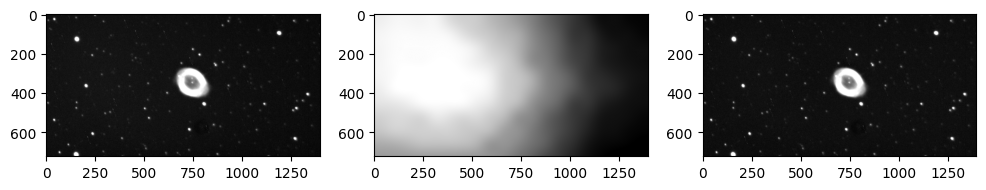

In [105]:
fig,ax = plt.subplots(1,3,figsize=(12,6))
lo,up = np.percentile(stack_median_black,1),np.percentile(stack_median_black,99)
ax[0].imshow(stack_median_black,cmap='gray',clim=(lo,up))
lo,up = np.percentile(bkg.background,1),np.percentile(bkg.background,95)
ax[1].imshow(bkg.background,cmap='gray',clim=(lo,up))
lo,up = np.percentile(stack_median_black-bkg.background,1),np.percentile(stack_median_black-bkg.background,99)
ax[2].imshow(image_sub_black,cmap='gray',clim=(lo,up))

Found 168 stars in image


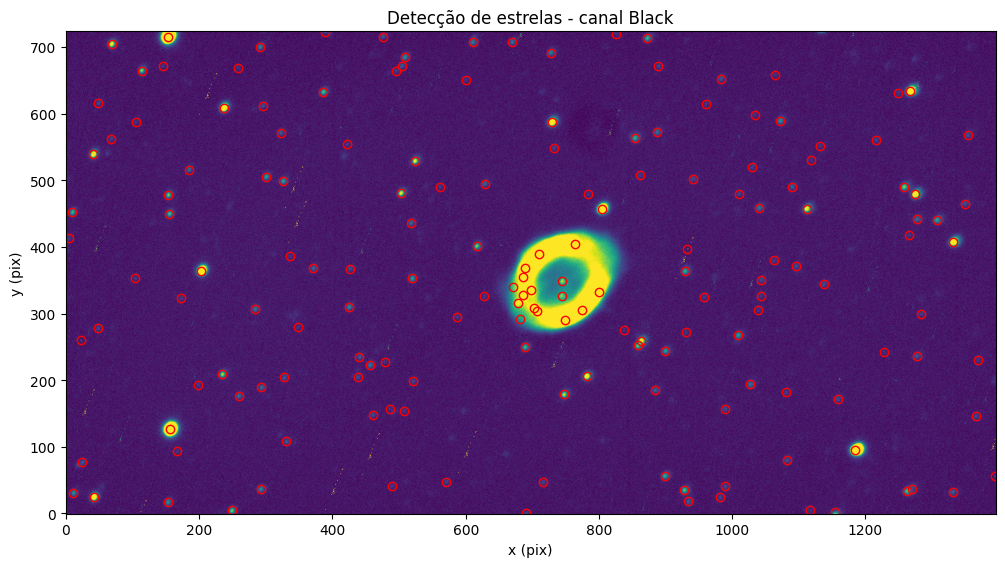

In [106]:
## Get background
mean, median, std = sigma_clipped_stats(image_sub_black, sigma=3.0, maxiters=20)

## Find stars
daofind = DAOStarFinder(fwhm=10.0, threshold=7*std)  ##peakmax pode ser usado para excluir saturadas
sources = daofind(image_sub_black - median)  # table with info of stars

print("Found %i stars in image" % len(sources))

# --- Plot da imagem ---
fig = plt.figure(figsize=(12,7))
l1 = np.percentile(image_sub_black[np.isfinite(image_sub_black)].flatten(), 1)
l2 = np.percentile(image_sub_black[np.isfinite(image_sub_black)].flatten(), 99)
plt.imshow(image_sub_black, clim=(l1, l2), origin='lower')
plt.plot(sources["xcentroid"], sources["ycentroid"], 'or', mfc='none')
plt.xlabel("x (pix)")
plt.ylabel("y (pix)")
plt.title("Detecção de estrelas - canal Black")
plt.show()


Background médio: -0.10620827


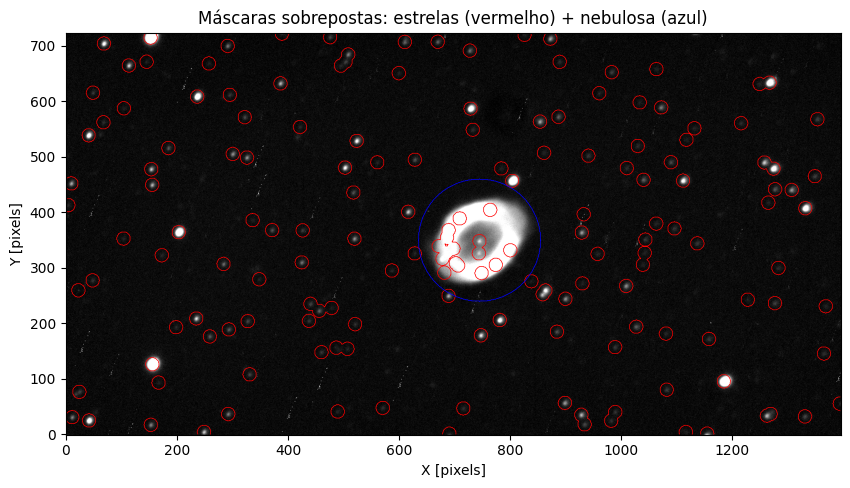

In [107]:
mask_stars = np.zeros(image_sub_black.shape, dtype=bool)

for star in sources:
    x = star['xcentroid']
    y = star['ycentroid']
    r = 12  # raio em pixels (ajuste conforme necessário)

    Y, X = np.ogrid[:image_sub_black.shape[0], :image_sub_black.shape[1]]
    dist = np.sqrt((X - x)**2 + (Y - y)**2)
    mask_stars[dist <= r] = True

mask_nebula = np.zeros(image_sub_black.shape, dtype=bool)

yc, xc = 350, 745   # centro da nebulosa
r_neb = 110         # raio em pixels

Y, X = np.ogrid[:image_sub_black.shape[0], :image_sub_black.shape[1]]
dist = np.sqrt((X - xc)**2 + (Y - yc)**2)
mask_nebula[dist <= r_neb] = True

mask_total = mask_stars | mask_nebula

background_values = image_sub_black[~mask_total]
mean_background = np.mean(background_values)
print("Background médio:", mean_background)

# --- Plot da imagem ---
plt.figure(figsize=(10,10))
plt.imshow(image_sub_black, origin='lower', cmap='gray',
           vmin=np.percentile(image_sub_black, 5),
           vmax=np.percentile(image_sub_black, 99))

# --- Máscara das estrelas em vermelho ---
plt.contour(mask_stars, colors='red', linewidths=0.5)

# --- Máscara da nebulosa em azul ---
plt.contour(mask_nebula, colors='blue', linewidths=0.5)

plt.title("Máscaras sobrepostas: estrelas (vermelho) + nebulosa (azul)")
plt.xlabel("X [pixels]")
plt.ylabel("Y [pixels]")
plt.show()
